# The Hohokam Pattern — Notebook 01: EDA

**Phase 3 of the weekly publishing project.** This notebook is for exploration only — it is allowed to be messy. Analytical work goes in Notebook 02. The goal here is to:

1. Load each dataset, verify it matches what `data_acquisition.md` describes
2. Check join compatibility across datasets
3. Look at univariate distributions and obvious spatial patterns
4. Surface data-quality issues before they become expensive in Phase 4
5. Record analytical decisions (what gets filtered, how missing values are handled, what scope we commit to)

Project folder assumed to be the current working directory.

## 1. Setup

In [1]:
# Standard imports
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore', category=UserWarning)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Paths — handle running from either project root or notebooks/
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
RAW = ROOT / 'data' / 'raw'
PROCESSED = ROOT / 'data' / 'processed'
PROCESSED.mkdir(parents=True, exist_ok=True)

print(f'Working from: {ROOT}')
print(f'Raw data:     {RAW}')
print(f'Processed:    {PROCESSED}')
print()
print('Files in raw/:')
for f in sorted(RAW.iterdir()):
    print(f'  {f.name:50s} {f.stat().st_size/1024:>10,.0f} KB')

Working from: /Users/seanjayasekera/Documents/Data Science Projects/Hohokam Pattern
Raw data:     /Users/seanjayasekera/Documents/Data Science Projects/Hohokam Pattern/data/raw
Processed:    /Users/seanjayasekera/Documents/Data Science Projects/Hohokam Pattern/data/processed

Files in raw/:
  climate_central_uhi_by_tract.xlsx                         486 KB
  maricopa_tracts_2024.gpkg                               3,120 KB
  nhd_canals_phoenix_metro.geojson                        1,518 KB
  phoenix_uhi_by_tract.csv                                   18 KB


## 2. Load datasets

### 2.1 Canal network (NHD-derived)

In [2]:
canals = gpd.read_file(RAW / 'nhd_canals_phoenix_metro.geojson')
print(f'Canal features: {len(canals):,}')
print(f'CRS: {canals.crs}')
print(f'Geometry types: {canals.geom_type.value_counts().to_dict()}')
print(f'Columns: {list(canals.columns)}')
canals.head(3)

Canal features: 1,475
CRS: EPSG:4326
Geometry types: {'LineString': 1475}
Columns: ['OBJECTID', 'permanent_identifier', 'fdate', 'resolution', 'gnis_id', 'gnis_name', 'lengthkm', 'reachcode', 'flowdir', 'wbarea_permanent_identifier', 'ftype', 'fcode', 'innetwork', 'mainpath', 'visibilityfilter', 'Shape_Length', 'globalid', 'geometry']


,OBJECTID,permanent_identifier,fdate,resolution,gnis_id,gnis_name,lengthkm,reachcode,flowdir,wbarea_permanent_identifier,ftype,fcode,innetwork,mainpath,visibilityfilter,Shape_Length,globalid,geometry
0,54057,136376199,1329615986000,2,NaN,NaN,1.092,15050100018089,0,NaN,336,33600,0,0,0,1312.028952,{7B0D6A31-4C77-11E1-BCF4-0021280458E6},"LINESTRING (-111.75221 33.20496, -111.75613 33..."
1,55247,136372271,1329615868000,2,NaN,NaN,0.807,15050100000430,0,NaN,336,33600,0,0,0,971.465503,{9B377572-4C72-11E1-BCF4-0021280458E6},"LINESTRING (-111.82441 33.33537, -111.82515 33..."
2,55473,136377319,1329616273000,2,NaN,NaN,1.125,15050100018465,0,NaN,336,33600,0,0,0,1354.363415,{F68C95D8-4C95-11E1-BCF4-0021280458E6},"LINESTRING (-111.94589 33.34912, -111.94597 33..."


In [3]:
# Quick null check on key fields
print('Null counts on key fields:')
for col in ['gnis_name', 'lengthkm', 'fcode', 'reachcode']:
    if col in canals.columns:
        null_n = canals[col].isna().sum()
        print(f'  {col:20s}  {null_n:>6,} nulls  ({100*null_n/len(canals):5.1f}%)')

Null counts on key fields:
  gnis_name              1,183 nulls  ( 80.2%)
  lengthkm                   0 nulls  (  0.0%)
  fcode                      0 nulls  (  0.0%)
  reachcode                  0 nulls  (  0.0%)


### 2.2 Census tract boundaries (Maricopa County)

In [4]:
tracts = gpd.read_file(RAW / 'maricopa_tracts_2024.gpkg')
print(f'Tract features: {len(tracts):,}')
print(f'CRS: {tracts.crs}')
print(f'Columns: {list(tracts.columns)}')

# Check GEOID format
print(f'\nGEOID sample: {tracts["GEOID"].head(3).tolist()}')
print(f'GEOID length consistency: {tracts["GEOID"].str.len().value_counts().to_dict()}')

# Land area summary (ALAND is in square meters)
tracts['area_km2'] = tracts['ALAND'] / 1_000_000
print(f'\nTract area summary (km²):')
print(tracts['area_km2'].describe().round(2).to_string())

Tract features: 1,009
CRS: EPSG:4269
Columns: ['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID', 'GEOIDFQ', 'NAME', 'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry']

GEOID sample: ['04013422656', '04013422658', '04013093104']
GEOID length consistency: {11: 1009}

Tract area summary (km²):
count    1009.00
mean       23.62
std       201.92
min         0.32
25%         1.46
50%         2.58
75%         3.97
max      3455.33


### 2.3 Urban heat island index (Climate Central)

In [5]:
uhi = pd.read_csv(RAW / 'phoenix_uhi_by_tract.csv', dtype={'GEOID': str})
print(f'UHI tracts: {len(uhi):,}')
print(f'Columns: {list(uhi.columns)}')
print(f'\nUHI index °F summary:')
print(uhi['uhi_index_f'].describe().round(2).to_string())

UHI tracts: 675
Columns: ['GEOID', 'uhi_index_c', 'uhi_index_f']

UHI index °F summary:
count    675.00
mean       7.47
std        0.91
min        5.08
25%        6.77
50%        7.87
75%        8.00
max       10.61


## 3. Cross-dataset validation

Three things to confirm before any analysis:
1. The UHI GEOIDs join cleanly to TIGER tracts
2. The canal CRS matches the tract CRS for spatial operations
3. The canal extent reasonably matches the Maricopa County extent

In [6]:
# UHI <> tracts join test
overlap = set(tracts['GEOID']) & set(uhi['GEOID'])
uhi_only = set(uhi['GEOID']) - set(tracts['GEOID'])
tracts_only = set(tracts['GEOID']) - set(uhi['GEOID'])

print(f'Maricopa tracts (TIGER):  {len(tracts):,}')
print(f'UHI tracts (Climate Cent.): {len(uhi):,}')
print(f'Join match:                 {len(overlap):,} tracts ({100*len(overlap)/len(uhi):.1f}% of UHI)')
print(f'In UHI but not TIGER:       {len(uhi_only):,}')
print(f'In TIGER but not UHI:       {len(tracts_only):,}  ← these are the metro tracts outside Phoenix proper')

Maricopa tracts (TIGER):  1,009
UHI tracts (Climate Cent.): 675
Join match:                 673 tracts (99.7% of UHI)
In UHI but not TIGER:       2
In TIGER but not UHI:       336  ← these are the metro tracts outside Phoenix proper


In [7]:
# CRS alignment for spatial ops
print(f'Canal CRS:  {canals.crs}')
print(f'Tract CRS:  {tracts.crs}')
print(f'Same CRS:   {canals.crs == tracts.crs}')

# Reproject if needed; for analysis we want a projected CRS (NAD83 / Arizona Central, ft, EPSG:2223)
# We will do this in Notebook 02. EDA stays in geographic for now.

Canal CRS:  EPSG:4326
Tract CRS:  EPSG:4269
Same CRS:   False


In [8]:
# Spatial extent check
print('Canal bounding box (lon, lat):')
print(f'  {canals.total_bounds}')
print('Tract bounding box:')
print(f'  {tracts.total_bounds}')

# Quick overlap check via centroid
canals_in_maricopa = canals[canals.intersects(tracts.unary_union)]
print(f'\nCanal features intersecting any Maricopa tract: {len(canals_in_maricopa):,} of {len(canals):,}')

Canal bounding box (lon, lat):
  [-112.65136699   33.07506643 -111.31975644   33.83668837]
Tract bounding box:
  [-113.335075   32.505059 -111.039905   34.04817 ]


/var/folders/s5/fxncr3_d39j27_97bgrrwg8c0000gn/T/ipykernel_18869/367920760.py:8: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  canals_in_maricopa = canals[canals.intersects(tracts.unary_union)]



Canal features intersecting any Maricopa tract: 1,436 of 1,475


## 4. Univariate exploration

### 4.1 Canal network

Total canal mileage in extract: 1447.0 mi
Per-segment length summary (mi):
count    1475.00
mean        0.98
std         1.27
min         0.00
25%         0.29
50%         0.59
75%         1.17
max        18.79


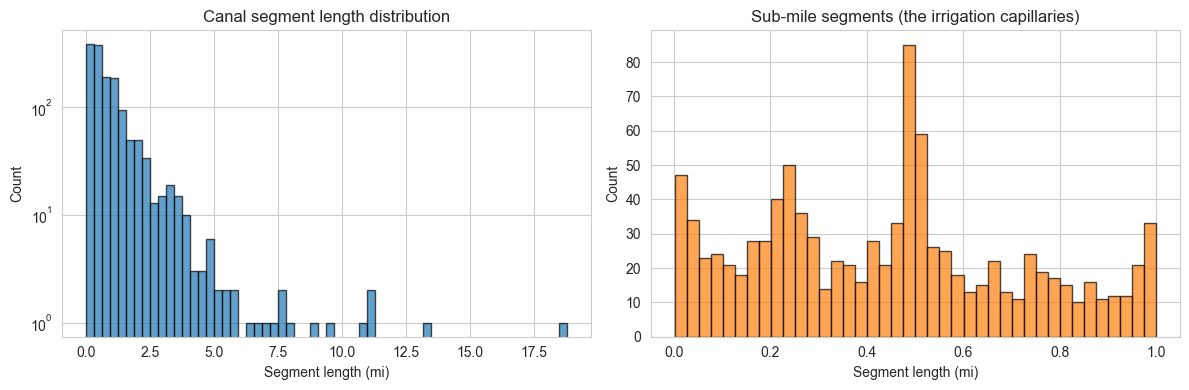

In [9]:
# Length distribution
length_mi = canals['lengthkm'] * 0.621371
print(f'Total canal mileage in extract: {length_mi.sum():.1f} mi')
print(f'Per-segment length summary (mi):')
print(length_mi.describe().round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(length_mi, bins=60, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Segment length (mi)')
axes[0].set_ylabel('Count')
axes[0].set_title('Canal segment length distribution')
axes[0].set_yscale('log')

axes[1].hist(length_mi[length_mi < 1], bins=40, edgecolor='black', alpha=0.7, color='C1')
axes[1].set_xlabel('Segment length (mi)')
axes[1].set_ylabel('Count')
axes[1].set_title('Sub-mile segments (the irrigation capillaries)')
plt.tight_layout()
plt.show()

In [10]:
# By named canal
by_name = (
    canals
    .assign(length_mi=length_mi)
    .groupby(canals['gnis_name'].fillna('(unnamed)'))['length_mi']
    .agg(['sum', 'count'])
    .sort_values('sum', ascending=False)
    .rename(columns={'sum': 'total_mi', 'count': 'segments'})
)
print('Top 15 canals by total mileage:')
print(by_name.head(15).round(1).to_string())

Top 15 canals by total mileage:
                                  total_mi  segments
gnis_name                                           
(unnamed)                           1043.5      1183
Central Arizona Project Aqueduct      99.2        62
Roosevelt Canal                       42.9        36
Arizona Canal                         38.2        33
Beardsley Canal                       30.2        27
Western Canal                         22.5        12
Grand Canal                           20.8        11
Eastern Canal                         20.1        24
Consolidated Canal East Branch        15.8        18
Buckeye Canal                         15.4         6
North Highline Lateral Canal           9.5         1
South Extension Canal                  7.4         2
Southern Canal                         6.6         3
Old Verde Canal                        6.3        18
Saint Johns Canal                      6.2         2


### 4.2 UHI index distribution

Climate Central documents the mean Phoenix UHI as 7.4°F. Our data should reproduce this within rounding.

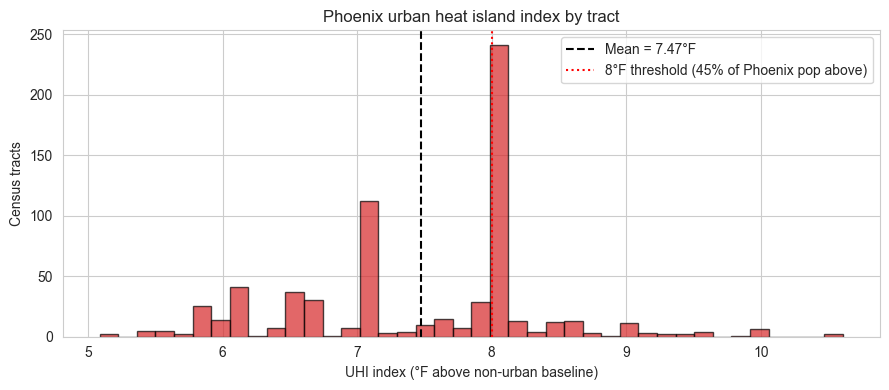

Tract-weighted mean UHI: 7.47°F
Median UHI:              7.87°F
Tracts >= 8°F UHI:       318 (47.1%)


In [11]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(uhi['uhi_index_f'], bins=40, edgecolor='black', alpha=0.7, color='C3')
ax.axvline(uhi['uhi_index_f'].mean(), color='black', linestyle='--', 
           label=f'Mean = {uhi["uhi_index_f"].mean():.2f}°F')
ax.axvline(8.0, color='red', linestyle=':', label='8°F threshold (45% of Phoenix pop above)')
ax.set_xlabel('UHI index (°F above non-urban baseline)')
ax.set_ylabel('Census tracts')
ax.set_title('Phoenix urban heat island index by tract')
ax.legend()
plt.tight_layout()
plt.show()

# Population-weighted summary (need ACS pop later)
print(f'Tract-weighted mean UHI: {uhi["uhi_index_f"].mean():.2f}°F')
print(f'Median UHI:              {uhi["uhi_index_f"].median():.2f}°F')
print(f'Tracts >= 8°F UHI:       {(uhi["uhi_index_f"] >= 8.0).sum()} ({100*(uhi["uhi_index_f"] >= 8.0).mean():.1f}%)')

### 4.3 Tract sizes

If a few extremely large tracts dominate the area, that will distort the area-weighted analyses later.

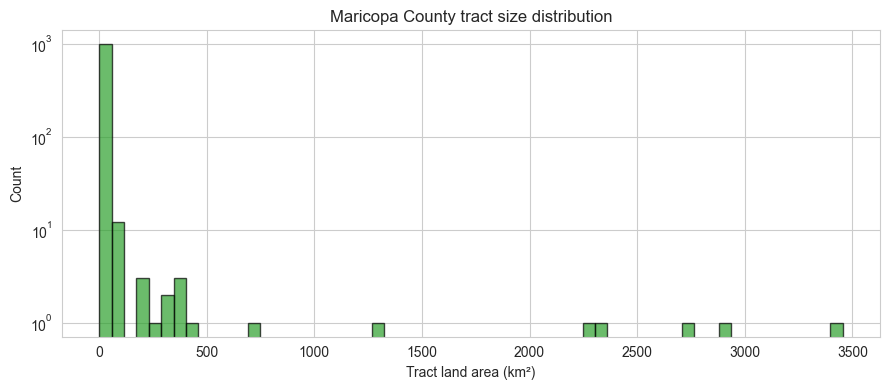

Largest 5 tracts by area:
      GEOID             NAMELSAD  area_km2
04013050603  Census Tract 506.03   3455.33
04013980100    Census Tract 9801   2912.72
04013010102  Census Tract 101.02   2707.87
04013723306 Census Tract 7233.06   2308.41
04013040515  Census Tract 405.15   2261.46

These are likely outer-metro rural tracts — flag them as candidates for trimming during analytical scoping.


In [12]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(tracts['area_km2'], bins=60, edgecolor='black', alpha=0.7, color='C2')
ax.set_xlabel('Tract land area (km²)')
ax.set_ylabel('Count')
ax.set_title('Maricopa County tract size distribution')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

print(f'Largest 5 tracts by area:')
print(tracts.nlargest(5, 'area_km2')[['GEOID', 'NAMELSAD', 'area_km2']].round(2).to_string(index=False))
print()
print('These are likely outer-metro rural tracts — flag them as candidates for trimming during analytical scoping.')

## 5. Spatial first look

Joined tracts: 1,009
With UHI value: 673


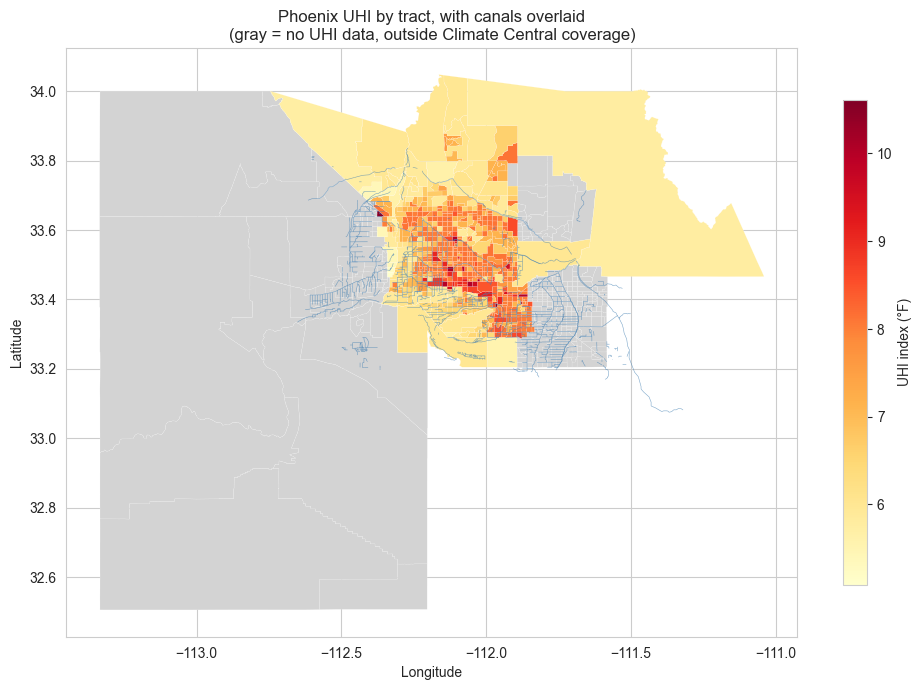

In [13]:
# Quick map: tracts colored by UHI where available
joined = tracts.merge(uhi[['GEOID', 'uhi_index_f']], on='GEOID', how='left')
print(f'Joined tracts: {len(joined):,}')
print(f'With UHI value: {joined["uhi_index_f"].notna().sum():,}')

fig, ax = plt.subplots(figsize=(10, 10))
# Tracts without UHI in gray
joined[joined['uhi_index_f'].isna()].plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.1)
# Tracts with UHI colored
joined[joined['uhi_index_f'].notna()].plot(
    ax=ax, column='uhi_index_f', cmap='YlOrRd', edgecolor='white', linewidth=0.1,
    legend=True, legend_kwds={'label': 'UHI index (°F)', 'shrink': 0.5}
)
# Canals on top
canals.plot(ax=ax, color='steelblue', linewidth=0.4, alpha=0.7)
ax.set_title('Phoenix UHI by tract, with canals overlaid\n(gray = no UHI data, outside Climate Central coverage)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

## 6. Analytical decisions log

Record decisions made during EDA so they're traceable later. Update this list as you go.

| # | Decision | Rationale | Date |
|---|----------|-----------|------|
| 1 | TBD: scope of analytical universe | Phoenix proper, full metro, or two-tier | YYYY-MM-DD |
| 2 | TBD: canal authority filtering | SRP only, or all five authorities | YYYY-MM-DD |
| 3 | TBD: handling of tracts without UHI | Drop, impute, or analyze separately | YYYY-MM-DD |
| 4 | TBD: handling of giant rural tracts | Keep, trim, or weight by population | YYYY-MM-DD |

Questions to resolve in Phase 4:
- Should the "canal-adjacent" definition be Euclidean distance to nearest canal (and at what threshold), or % of tract area within some buffer, or both?
- For clustering, should we standardize features and use Ward linkage as cross-check on K-Means?
- For Bayesian A/B, what prior is defensible? Probably weakly-informative normal centered at zero, since we have no strong prior that canal-adjacent tracts must be cooler.

## 7. Save processed working dataframe

Output a single tract-level dataframe with everything joined, ready for Notebook 02.

In [14]:
# Build the working tract-level dataframe
working = tracts.merge(uhi[['GEOID', 'uhi_index_f', 'uhi_index_c']], on='GEOID', how='left')

# Placeholder columns for ACS variables (filled in once API key acquired)
acs_placeholder_cols = [
    'pop_total', 'median_hh_income', 'median_home_value', 'median_rent',
    'pct_white', 'pct_black', 'pct_hispanic', 'median_year_built',
    'pct_owner_occupied'
]
for col in acs_placeholder_cols:
    working[col] = np.nan

# Placeholder for canal-proximity features (computed in Notebook 02)
working['nearest_canal_m'] = np.nan
working['canal_length_in_tract_m'] = np.nan
working['has_srp_canal'] = np.nan

# Save
working_path = PROCESSED / 'tracts_working.gpkg'
working.to_file(working_path, driver='GPKG')
print(f'Saved working dataframe to {working_path}')
print(f'Shape: {working.shape}')
print(f'\nColumn inventory:')
for c in working.columns:
    n_null = working[c].isna().sum() if c != 'geometry' else 0
    print(f'  {c:30s}  {n_null:>5,} nulls')

Saved working dataframe to /Users/seanjayasekera/Documents/Data Science Projects/Hohokam Pattern/data/processed/tracts_working.gpkg
Shape: (1009, 29)

Column inventory:
  STATEFP                             0 nulls
  COUNTYFP                            0 nulls
  TRACTCE                             0 nulls
  GEOID                               0 nulls
  GEOIDFQ                             0 nulls
  NAME                                0 nulls
  NAMELSAD                            0 nulls
  MTFCC                               0 nulls
  FUNCSTAT                            0 nulls
  ALAND                               0 nulls
  AWATER                              0 nulls
  INTPTLAT                            0 nulls
  INTPTLON                            0 nulls
  geometry                            0 nulls
  area_km2                            0 nulls
  uhi_index_f                       336 nulls
  uhi_index_c                       336 nulls
  pop_total                       1,009 nulls
  m

## 8. Next steps

When ACS data arrives:
1. Load `data/raw/acs_2023_5yr_maricopa_tracts.csv`
2. Re-run this notebook from section 2 to populate the placeholder columns
3. Add ACS univariate exploration to section 4

Then proceed to Notebook 02 (`02_analysis.ipynb`), which will:
- Compute canal-proximity features (nearest-distance and length-within-buffer)
- Run K-Means clustering with PCA visualization
- Run the dual-track A/B (frequentist + Bayesian) on canal-adjacent vs canal-distant
- Bootstrap CIs throughout
- Generate the publication figures (drafts)